# 02 - DLIB Facial Landmark & Lip ROI Extraction Pipeline (Full Dataset)
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Implement an end-to-end facial landmark detection and mouth region-of-interest (ROI) cropping pipeline using **DLIB 68-point facial landmarks** across the **entire Tai Phake digits dataset**:
- **30 Speakers**: `s1` through `s30`
- **11 Digits**: `d0` through `d10`
- **330 Total Speaker-Digit Combinations** (~14,800+ total frames)

### Pipeline Overview:
1. **Input Dataset**: Discovers video frames organized by speaker (`s1`–`s30`) and digit class (`d0`–`d10`) dynamically from `data/digit/`.
2. **Face Detection**: Detects faces using DLIB's frontal face detector (`dlib.get_frontal_face_detector()`), selecting the largest face.
3. **68 Facial Landmarks**: Detects 68 facial landmarks using `shape_predictor_68_face_landmarks.dat`.
4. **Mouth ROI Extraction**: Extracts mouth landmarks **48–67**, computes bounding box with configurable padding (`PADDING_X`, `PADDING_Y`), and clips to image boundaries.
5. **Preprocessing & Resizing**: Resizes cropped mouth ROI to a consistent **96×96** pixels using `cv2.INTER_AREA`, preserving RGB color information.
6. **Output Organization**: Saves cropped lip frames into `data/cropped_lips_dataset/sX/dY/` preserving the original `speaker/digit/frame_xxx.jpg` hierarchy.
7. **Validation & Verification**: Verifies all 330 combinations, tracks failures with reasons, generates summary tables, and displays random verification samples.

In [11]:
# Cell 1: Imports
import os
import sys
import random
from pathlib import Path
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print(f"OpenCV Version: {cv2.__version__}")
print(f"DLIB Version:   {dlib.__version__}")
print(f"NumPy Version:  {np.__version__}")

OpenCV Version: 5.0.0
DLIB Version:   20.0.1
NumPy Version:  2.5.3


In [12]:
# Cell 2: Configuration
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# Dataset and Model Paths (Relative & robust using pathlib)
INPUT_ROOT = PROJECT_ROOT / "data" / "digit"
OUTPUT_ROOT = PROJECT_ROOT / "data" / "cropped_lips_dataset"
DLIB_PREDICTOR_PATH = PROJECT_ROOT / "models" / "dlib" / "shape_predictor_68_face_landmarks.dat"
RESULTS_DIR = PROJECT_ROOT / "results" / "dlib"

# Output Lip Image Dimensions
IMG_WIDTH = 96
IMG_HEIGHT = 96

# Configurable Mouth ROI Padding (in pixels)
PADDING_X = 15
PADDING_Y = 10

# Pipeline Control Flags
OVERWRITE = False            # If False, skip already cropped frames; if True, reprocess everything
CONVERT_GRAYSCALE = False    # Retain RGB color if False; convert to grayscale if True
SAVE_VISUALIZATIONS = True   # Save debug annotated images to RESULTS_DIR

# Supported Image File Formats
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

# Expected Dataset Hierarchy (30 Speakers x 11 Digits = 330 Combinations)
EXPECTED_SPEAKERS = [f"s{i}" for i in range(1, 31)]
EXPECTED_DIGITS = [f"d{i}" for i in range(11)]

print(f"Project Root:        {PROJECT_ROOT.resolve()}")
print(f"Input Dataset:       {INPUT_ROOT.resolve()}")
print(f"Output Dataset:      {OUTPUT_ROOT.resolve()}")
print(f"DLIB Predictor:      {DLIB_PREDICTOR_PATH.resolve()}")
print(f"Results Directory:   {RESULTS_DIR.resolve()}")
print(f"Target Lip Size:     {IMG_WIDTH}x{IMG_HEIGHT}")
print(f"Padding:             X={PADDING_X}px, Y={PADDING_Y}px")
print(f"Overwrite Existing:  {OVERWRITE}")
print(f"Convert Grayscale:   {CONVERT_GRAYSCALE}")
print(f"Expected Classes:    {len(EXPECTED_SPEAKERS)} speakers x {len(EXPECTED_DIGITS)} digits = {len(EXPECTED_SPEAKERS)*len(EXPECTED_DIGITS)} combinations")

Project Root:        /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Input Dataset:       /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit
Output Dataset:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/cropped_lips_dataset
DLIB Predictor:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/models/dlib/shape_predictor_68_face_landmarks.dat
Results Directory:   /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib
Target Lip Size:     96x96
Padding:             X=15px, Y=10px
Overwrite Existing:  False
Convert Grayscale:   False
Expected Classes:    30 speakers x 11 digits = 330 combinations


In [13]:
# Cell 3: Verify Paths & DLIB Model Existence
# 1. Verify Input Dataset
if not INPUT_ROOT.exists():
    raise FileNotFoundError(f"Input dataset directory not found: {INPUT_ROOT.resolve()}.")
speaker_dirs = [d for d in INPUT_ROOT.iterdir() if d.is_dir() and d.name.startswith("s")]
print(f"[OK] Input dataset found with {len(speaker_dirs)} speaker folders in {INPUT_ROOT}.")

# 2. Verify DLIB 68-Point Facial Landmark Predictor
if not DLIB_PREDICTOR_PATH.exists():
    print("=" * 80)
    print("ERROR: DLIB 68-point landmark predictor NOT FOUND!")
    print(f"Expected location: {DLIB_PREDICTOR_PATH.resolve()}")
    print("Please place 'shape_predictor_68_face_landmarks.dat' inside:")
    print(f"  {DLIB_PREDICTOR_PATH.parent.resolve()}")
    print("Download URL: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2")
    print("=" * 80)
    raise FileNotFoundError(f"Missing DLIB predictor file: {DLIB_PREDICTOR_PATH}")
else:
    file_size_mb = DLIB_PREDICTOR_PATH.stat().st_size / (1024 * 1024)
    print(f"[OK] DLIB landmark predictor found: {DLIB_PREDICTOR_PATH.name} ({file_size_mb:.2f} MB)")

# 3. Create Output and Results Directories
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"[OK] Output directory ready:  {OUTPUT_ROOT.resolve()}")
print(f"[OK] Results directory ready: {RESULTS_DIR.resolve()}")

[OK] Input dataset found with 30 speaker folders in /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit.
[OK] DLIB landmark predictor found: shape_predictor_68_face_landmarks.dat (95.08 MB)
[OK] Output directory ready:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/cropped_lips_dataset
[OK] Results directory ready: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib


In [14]:
# Cell 4: Initialize DLIB Face Detector & Shape Predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(str(DLIB_PREDICTOR_PATH))

print("DLIB frontal face detector & 68-point shape predictor initialized successfully.")

DLIB frontal face detector & 68-point shape predictor initialized successfully.


In [15]:
# Cell 5: Helper Function - Detect Face and 68 Landmarks
def detect_landmarks(image):
    """
    Detects the largest face in an image and extracts 68 facial landmarks.

    Parameters:
        image (np.ndarray): Input BGR image.

    Returns:
        tuple: (landmarks_points, face_rect, error_message)
               - landmarks_points: np.ndarray of shape (68, 2) or None
               - face_rect: dlib.rectangle object of the detected face or None
               - error_message: str describing issue if failed, else None
    """
    if image is None or image.size == 0:
        return None, None, "Unreadable or empty image"

    # Convert image to grayscale for DLIB detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces using frontal face detector
    faces = detector(gray, 1)

    if len(faces) == 0:
        return None, None, "No face detected"

    # Select the largest face based on bounding box area (to avoid selecting background faces)
    largest_face = max(faces, key=lambda rect: (rect.right() - rect.left()) * (rect.bottom() - rect.top()))

    # Predict 68 facial landmarks
    try:
        shape = predictor(gray, largest_face)
        landmarks = np.array([[shape.part(i).x, shape.part(i).y] for i in range(68)], dtype=np.int32)
        return landmarks, largest_face, None
    except Exception as e:
        return None, largest_face, f"Landmark prediction error: {str(e)}"

In [16]:
# Cell 6: Helper Functions - Extract Lip ROI & Create Debug Visualizations
def extract_lip_region(image, landmarks, pad_x=PADDING_X, pad_y=PADDING_Y,
                       target_w=IMG_WIDTH, target_h=IMG_HEIGHT, to_gray=CONVERT_GRAYSCALE):
    """
    Extracts, pads, crops, and resizes the mouth/lip ROI from landmarks (points 48-67).

    Parameters:
        image (np.ndarray): Input BGR image.
        landmarks (np.ndarray): Array of shape (68, 2) with facial landmarks.
        pad_x (int): Horizontal padding around mouth landmarks in pixels.
        pad_y (int): Vertical padding around mouth landmarks in pixels.
        target_w (int): Target width for the cropped lip image.
        target_h (int): Target height for the cropped lip image.
        to_gray (bool): Whether to convert cropped image to grayscale.

    Returns:
        tuple: (cropped_lip, bbox_coords, error_message)
               - cropped_lip: Resized np.ndarray of shape (target_h, target_w, [3]) or None
               - bbox_coords: (x1, y1, x2, y2) bounding box before resize
               - error_message: str describing issue if failed, else None
    """
    if landmarks is None or len(landmarks) < 68:
        return None, None, "Invalid or incomplete landmarks"

    img_h, img_w = image.shape[:2]

    # DLIB mouth landmark convention: points 48 to 67 (inclusive, 20 points)
    mouth_points = landmarks[48:68]

    min_x, min_y = np.min(mouth_points, axis=0)
    max_x, max_y = np.max(mouth_points, axis=0)

    # Apply configurable padding around the mouth
    x1 = max(0, int(min_x - pad_x))
    y1 = max(0, int(min_y - pad_y))
    x2 = min(img_w, int(max_x + pad_x))
    y2 = min(img_h, int(max_y + pad_y))

    # Validate crop dimensions
    if (x2 - x1) <= 0 or (y2 - y1) <= 0:
        return None, None, f"Invalid crop coordinates: ({x1}, {y1}) to ({x2}, {y2})"

    # Crop lip region
    lip_crop = image[y1:y2, x1:x2]

    # Optional grayscale conversion
    if to_gray:
        if len(lip_crop.shape) == 3:
            lip_crop = cv2.cvtColor(lip_crop, cv2.COLOR_BGR2GRAY)

    # Resize to fixed standard dimensions (cv2.INTER_AREA for crisp downsampling)
    resized_lip = cv2.resize(lip_crop, (target_w, target_h), interpolation=cv2.INTER_AREA)

    return resized_lip, (x1, y1, x2, y2), None

def create_debug_visualization(image, face_rect, landmarks, lip_bbox):
    """
    Creates an annotated copy of the original frame with face box, landmarks, and lip crop box.
    """
    vis_img = image.copy()

    # 1. Draw face bounding box (Cyan)
    if face_rect is not None:
        cv2.rectangle(vis_img, (face_rect.left(), face_rect.top()),
                      (face_rect.right(), face_rect.bottom()), (255, 255, 0), 2)
        cv2.putText(vis_img, "Face", (face_rect.left(), max(20, face_rect.top() - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

    # 2. Draw 68 landmarks (Blue: non-mouth, Green: outer lip, Yellow: inner lip)
    if landmarks is not None:
        for idx, (x, y) in enumerate(landmarks):
            if idx < 48:
                cv2.circle(vis_img, (int(x), int(y)), 2, (255, 100, 0), -1)
            elif 48 <= idx <= 59:
                cv2.circle(vis_img, (int(x), int(y)), 3, (0, 255, 0), -1)  # Outer lip (48-59)
            else:
                cv2.circle(vis_img, (int(x), int(y)), 3, (0, 255, 255), -1) # Inner lip (60-67)

    # 3. Draw mouth crop bounding box (Red)
    if lip_bbox is not None:
        x1, y1, x2, y2 = lip_bbox
        cv2.rectangle(vis_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(vis_img, "Mouth Crop", (x1, max(20, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    return vis_img

Running single-frame test on: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit/s1/d0/frame_0028.jpg
Visual verification image saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib/single_frame_verification.jpg


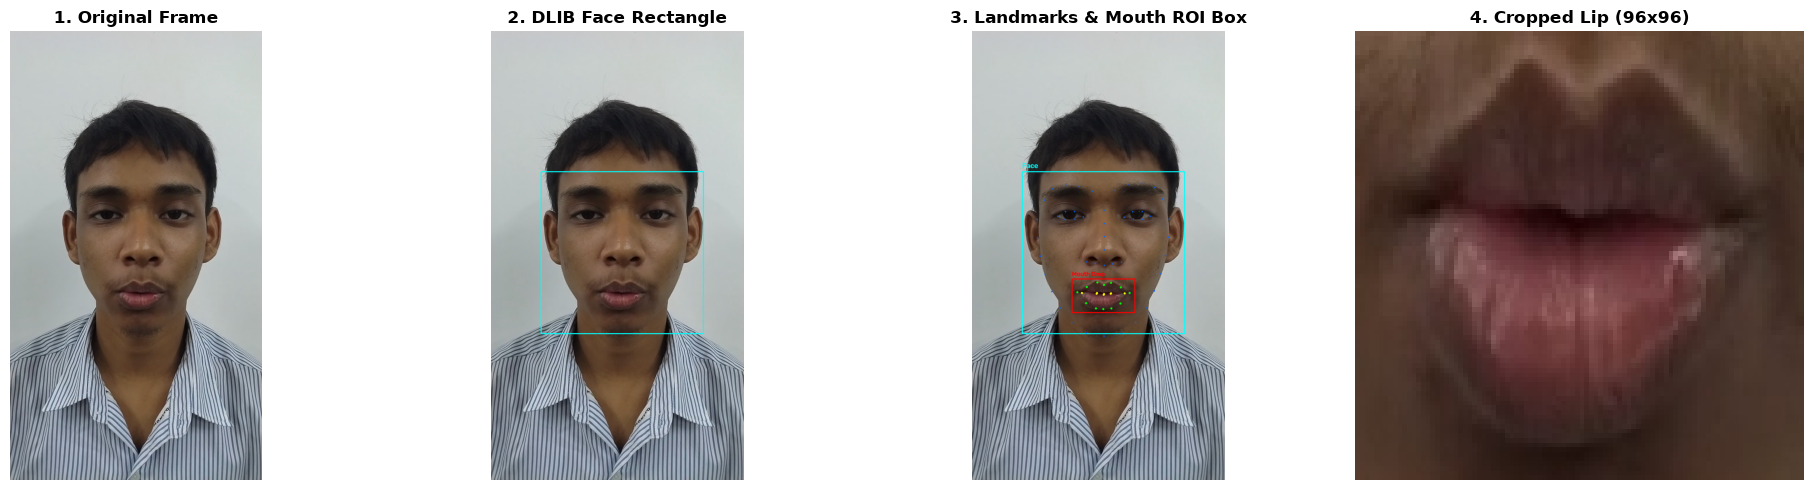

--- Verification Metrics ---
Face Box:   (142, 400) to (605, 862)
Mouth Crop: (284, 706) to (463, 802)
Cropped Lip Output Dimensions: (96, 96, 3)


In [17]:
# Cell 7: Test Pipeline on a Single Frame (Visual Verification)
sample_frame_path = next(INPUT_ROOT.glob("s1/d0/*.jpg"), None)
if sample_frame_path is None:
    sample_frame_path = next(INPUT_ROOT.glob("*/*/*.jpg"), None)

if sample_frame_path is None:
    raise FileNotFoundError("No image frames found in input dataset!")

print(f"Running single-frame test on: {sample_frame_path}")
sample_img = cv2.imread(str(sample_frame_path))
landmarks, face_rect, err = detect_landmarks(sample_img)

if err is not None:
    print(f"Detection failed on sample frame: {err}")
else:
    cropped_lip, lip_bbox, crop_err = extract_lip_region(sample_img, landmarks)

    # Face rectangle only visualization
    face_only_vis = sample_img.copy()
    if face_rect is not None:
        cv2.rectangle(face_only_vis, (face_rect.left(), face_rect.top()),
                      (face_rect.right(), face_rect.bottom()), (255, 255, 0), 2)

    # Full annotated visualization (face + 68 landmarks + mouth crop box)
    annotated_vis = create_debug_visualization(sample_img, face_rect, landmarks, lip_bbox)

    # Save visual verification to results/dlib/
    if SAVE_VISUALIZATIONS:
        vis_save_path = RESULTS_DIR / "single_frame_verification.jpg"
        cv2.imwrite(str(vis_save_path), annotated_vis)
        print(f"Visual verification image saved to: {vis_save_path}")

    # Display 4-panel visual verification
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Original Frame", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(face_only_vis, cv2.COLOR_BGR2RGB))
    axes[1].set_title("2. DLIB Face Rectangle", fontsize=12, fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(cv2.cvtColor(annotated_vis, cv2.COLOR_BGR2RGB))
    axes[2].set_title("3. Landmarks & Mouth ROI Box", fontsize=12, fontweight="bold")
    axes[2].axis("off")

    if CONVERT_GRAYSCALE:
        axes[3].imshow(cropped_lip, cmap="gray")
    else:
        axes[3].imshow(cv2.cvtColor(cropped_lip, cv2.COLOR_BGR2RGB))
    axes[3].set_title(f"4. Cropped Lip ({IMG_WIDTH}x{IMG_HEIGHT})", fontsize=12, fontweight="bold")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    print("--- Verification Metrics ---")
    print(f"Face Box:   ({face_rect.left()}, {face_rect.top()}) to ({face_rect.right()}, {face_rect.bottom()})")
    print(f"Mouth Crop: ({lip_bbox[0]}, {lip_bbox[1]}) to ({lip_bbox[2]}, {lip_bbox[3]})")
    print(f"Cropped Lip Output Dimensions: {cropped_lip.shape}")

In [18]:
# Cell 8: Test Batch Pipeline on s1/d0
test_speaker = "s1"
test_digit = "d0"
test_in_dir = INPUT_ROOT / test_speaker / test_digit
test_out_dir = OUTPUT_ROOT / test_speaker / test_digit
test_out_dir.mkdir(parents=True, exist_ok=True)

test_frames = sorted([f for f in test_in_dir.iterdir() if f.suffix.lower() in VALID_EXTENSIONS])
print(f"Testing batch pipeline on {test_speaker}/{test_digit} ({len(test_frames)} frames)...\n")

s1_success = 0
s1_skipped = 0
s1_failed = 0

for frame_path in test_frames:
    out_path = test_out_dir / frame_path.name
    if out_path.exists() and not OVERWRITE:
        s1_skipped += 1
        s1_success += 1
        continue

    img = cv2.imread(str(frame_path))
    if img is None:
        s1_failed += 1
        continue

    landmarks, face_rect, err = detect_landmarks(img)
    if err is not None:
        s1_failed += 1
        continue

    cropped_lip, bbox, crop_err = extract_lip_region(img, landmarks)
    if crop_err is not None or cropped_lip is None:
        s1_failed += 1
        continue

    cv2.imwrite(str(out_path), cropped_lip)
    s1_success += 1

print(f"Results for test {test_speaker}/{test_digit}:")
print(f"  Total frames:        {len(test_frames)}")
print(f"  Successfully saved:  {s1_success}")
print(f"  Skipped (existing):  {s1_skipped}")
print(f"  Failed:              {s1_failed}")

Testing batch pipeline on s1/d0 (40 frames)...

Results for test s1/d0:
  Total frames:        40
  Successfully saved:  40
  Skipped (existing):  0
  Failed:              0


In [19]:
# Cell 9: Process ALL Speakers (s1-s30) and ALL Digits (d0-d10)
def process_full_dataset(input_root=INPUT_ROOT, output_root=OUTPUT_ROOT, overwrite=OVERWRITE):
    """
    Iterates across all 30 speakers and 11 digits (330 combinations),
    extracts mouth ROIs using DLIB, resizes to standard dimensions (96x96),
    and saves cropped frames to data/cropped_lips_dataset/sX/dY/frame_ZZZZ.jpg.
    """
    stats = {
        "speakers_found": 0,
        "digits_per_speaker": 11,
        "expected_combinations": 330,
        "combinations_processed": 0,
        "total_input_frames": 0,
        "successfully_cropped": 0,
        "skipped_existing": 0,
        "failed_total": 0,
        "no_face_detected": 0,
        "landmark_failure": 0,
        "invalid_crop": 0,
        "unreadable_images": 0,
    }
    failed_frames = []

    # Matrix for per-speaker successfully cropped frames: {speaker: {digit: count}}
    per_speaker_counts = {spk: {d: 0 for d in EXPECTED_DIGITS} for spk in EXPECTED_SPEAKERS}

    # Discover existing speaker directories dynamically and sort naturally (s1, s2, ..., s30)
    discovered_speakers = sorted(
        [d for d in input_root.iterdir() if d.is_dir() and d.name.startswith("s")],
        key=lambda p: (int(p.name[1:]) if p.name[1:].isdigit() else p.name)
    )
    stats["speakers_found"] = len(discovered_speakers)
    print(f"Discovered {len(discovered_speakers)} speaker directories in {input_root}.")
    print(f"Processing all 30 speakers x 11 digits (330 combinations)...\n")

    # Progress bar across all 30 speakers
    for speaker_idx, speaker_id in enumerate(tqdm(EXPECTED_SPEAKERS, desc="Speakers (s1-s30)")):
        speaker_dir = input_root / speaker_id
        if not speaker_dir.exists():
            print(f"WARNING: Missing speaker folder: {speaker_id}")
            continue

        for digit_id in EXPECTED_DIGITS:
            digit_dir = speaker_dir / digit_id
            dest_digit_dir = output_root / speaker_id / digit_id

            if not digit_dir.exists():
                print(f"WARNING: Missing folder: {speaker_id}/{digit_id}")
                continue

            # Create destination folder: data/cropped_lips_dataset/sX/dY/
            dest_digit_dir.mkdir(parents=True, exist_ok=True)
            stats["combinations_processed"] += 1

            # Find all image frames
            frame_files = sorted([f for f in digit_dir.iterdir() if f.suffix.lower() in VALID_EXTENSIONS])

            if len(frame_files) == 0:
                print(f"WARNING: No frames found: {speaker_id}/{digit_id}")
                continue

            combo_success = 0
            for frame_file in frame_files:
                stats["total_input_frames"] += 1
                dest_file = dest_digit_dir / frame_file.name

                # Avoid reprocessing if already saved and overwrite is False
                if dest_file.exists() and not overwrite:
                    stats["skipped_existing"] += 1
                    stats["successfully_cropped"] += 1
                    combo_success += 1
                    continue

                # 1. Read image
                img = cv2.imread(str(frame_file))
                if img is None or img.size == 0:
                    stats["unreadable_images"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": "Unreadable image"})
                    continue

                # 2. DLIB Face & 68 Landmark Detection
                landmarks, face_rect, err = detect_landmarks(img)
                if err is not None:
                    if "No face" in err:
                        stats["no_face_detected"] += 1
                    else:
                        stats["landmark_failure"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": err})
                    continue

                # 3. Extract, pad, crop, and resize lip region (96x96)
                cropped_lip, bbox, crop_err = extract_lip_region(img, landmarks)
                if crop_err is not None or cropped_lip is None:
                    stats["invalid_crop"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": crop_err or "Invalid crop"})
                    continue

                # 4. Save cropped lip frame preserving exact filename
                saved = cv2.imwrite(str(dest_file), cropped_lip)
                if saved:
                    stats["successfully_cropped"] += 1
                    combo_success += 1
                else:
                    stats["invalid_crop"] += 1
                    stats["failed_total"] += 1
                    failed_frames.append({"path": str(frame_file), "speaker": speaker_id, "digit": digit_id, "reason": "Write failure"})

            per_speaker_counts[speaker_id][digit_id] = combo_success

    return stats, failed_frames, per_speaker_counts

# Execute processing across the entire dataset (all 30 speakers x 11 digits)
stats, failed_frames, per_speaker_counts = process_full_dataset()

Discovered 30 speaker directories in /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit.
Processing all 30 speakers x 11 digits (330 combinations)...



Speakers (s1-s30): 100%|████████████████████████████| 30/30 [39:40<00:00, 79.35s/it]


In [20]:
# Cell 10: Summary Report & Per-Speaker Breakdown Table
print("=" * 50)
print("          DLIB LIP EXTRACTION SUMMARY")
print("=" * 50)
print(f"Speakers found:                       {stats['speakers_found']}")
print(f"Digits per speaker:                   {stats['digits_per_speaker']}")
print(f"Expected speaker-digit combinations:  {stats['expected_combinations']}")
print(f"Speaker-digit combinations processed: {stats['combinations_processed']}")
print("")
print(f"Total input frames:                   {stats['total_input_frames']}")
print(f"Successfully cropped:                 {stats['successfully_cropped']}")
print(f"Skipped (already existing):           {stats['skipped_existing']}")
print(f"Failed:                               {stats['failed_total']}")
print("")
print(f"No face detected:                     {stats['no_face_detected']}")
print(f"Landmark failure:                     {stats['landmark_failure']}")
print(f"Invalid crop:                         {stats['invalid_crop']}")
print(f"Unreadable images:                    {stats['unreadable_images']}")
print("")
print("Output directory:")
print(f"{OUTPUT_ROOT.resolve()}")
print("=" * 50)

# Print formatted Per-Speaker Summary Table
print("\n" + "=" * 95)
print("                   PER-SPEAKER SUCCESSFULLY CROPPED LIP FRAMES SUMMARY")
print("=" * 95)

headers = ["Speaker"] + EXPECTED_DIGITS + ["Total"]
header_row = f"{headers[0]:<9}" + "".join(f"{h:>7}" for h in headers[1:])
print(header_row)
print("-" * len(header_row))

digit_column_totals = {d: 0 for d in EXPECTED_DIGITS}
grand_total = 0

for spk in EXPECTED_SPEAKERS:
    spk_data = per_speaker_counts.get(spk, {d: 0 for d in EXPECTED_DIGITS})
    spk_total = sum(spk_data.get(d, 0) for d in EXPECTED_DIGITS)
    grand_total += spk_total
    for d in EXPECTED_DIGITS:
        digit_column_totals[d] += spk_data.get(d, 0)

    row_str = f"{spk:<9}" + "".join(f"{spk_data.get(d, 0):>7}" for d in EXPECTED_DIGITS) + f"{spk_total:>7}"
    print(row_str)

print("-" * len(header_row))
total_row_str = f"{'Total':<9}" + "".join(f"{digit_column_totals[d]:>7}" for d in EXPECTED_DIGITS) + f"{grand_total:>7}"
print(total_row_str)
print("=" * 95)

if len(failed_frames) > 0:
    print(f"\nSample failed frames ({min(10, len(failed_frames))} of {len(failed_frames)} failures):")
    for item in failed_frames[:10]:
        print(f"  [{item['speaker']}/{item['digit']}] {Path(item['path']).name} -> Reason: {item['reason']}")
else:
    print("\n[100% SUCCESS] All frames across all 30 speakers and 11 digits were successfully processed!")

          DLIB LIP EXTRACTION SUMMARY
Speakers found:                       30
Digits per speaker:                   11
Expected speaker-digit combinations:  330
Speaker-digit combinations processed: 330

Total input frames:                   14881
Successfully cropped:                 14279
Skipped (already existing):           40
Failed:                               602

No face detected:                     602
Landmark failure:                     0
Invalid crop:                         0
Unreadable images:                    0

Output directory:
/Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/cropped_lips_dataset

                   PER-SPEAKER SUCCESSFULLY CROPPED LIP FRAMES SUMMARY
Speaker       d0     d1     d2     d3     d4     d5     d6     d7     d8     d9    d10  Total
---------------------------------------------------------------------------------------------
s1            40     39     40     36     48     55     35     41     42     36     30    442

In [21]:
# Cell 11: Automatic Dataset Validation & Discrepancy Reporting
print("=" * 75)
print("             AUTOMATIC OUTPUT DATASET VERIFICATION")
print("=" * 75)

# 1. Verify Speaker Folders (s1 through s30)
output_speakers = sorted(
    [d.name for d in OUTPUT_ROOT.iterdir() if d.is_dir() and d.name.startswith("s")],
    key=lambda name: (int(name[1:]) if name[1:].isdigit() else name)
)
missing_speakers = [s for s in EXPECTED_SPEAKERS if s not in output_speakers]
print(f"1. Speaker Folders Check: {len(output_speakers)}/30 speakers present.")
if missing_speakers:
    print(f"   [WARNING] Missing speaker directories: {missing_speakers}")
else:
    print("   [PASS] All 30 speaker folders (s1 to s30) exist.")

# 2. Verify Digit Folders (d0 through d10 for each speaker)
missing_combos = []
for s in EXPECTED_SPEAKERS:
    spk_path = OUTPUT_ROOT / s
    for d in EXPECTED_DIGITS:
        if not (spk_path / d).exists():
            missing_combos.append(f"{s}/{d}")

print(f"\n2. Digit Folders Check: {330 - len(missing_combos)}/330 combinations present.")
if missing_combos:
    print(f"   [WARNING] Missing combinations: {missing_combos[:10]} ...")
else:
    print("   [PASS] All 11 digits (d0 to d10) exist for all 30 speakers.")

# 3. Compare Frame Counts Between Input and Output
print("\n3. Comparing Frame Counts (Input data/digit/ vs Output data/cropped_lips_dataset/):")
discrepancies = []
total_input_verified = 0
total_output_verified = 0

for s in EXPECTED_SPEAKERS:
    for d in EXPECTED_DIGITS:
        in_dir = INPUT_ROOT / s / d
        out_dir = OUTPUT_ROOT / s / d

        in_count = len([f for f in in_dir.glob("*.*") if f.suffix.lower() in VALID_EXTENSIONS]) if in_dir.exists() else 0
        out_count = len([f for f in out_dir.glob("*.*") if f.suffix.lower() in VALID_EXTENSIONS]) if out_dir.exists() else 0

        total_input_verified += in_count
        total_output_verified += out_count

        if in_count != out_count:
            failed_diff = in_count - out_count
            discrepancies.append((f"{s}/{d}", in_count, out_count, failed_diff))

print(f"   Total input frames verified:  {total_input_verified}")
print(f"   Total output frames verified: {total_output_verified}")

if discrepancies:
    print(f"\n   [NOTICE] Found {len(discrepancies)} combinations with dropped/failed frames:")
    for combo, in_c, out_c, diff in discrepancies[:15]:
        print(f"     {combo}: input={in_c}, output={out_c}, failed={diff}")
    if len(discrepancies) > 15:
        print(f"     ... and {len(discrepancies) - 15} more combinations.")
else:
    print("   [PASS] Perfect 1:1 match across all combinations! Zero dropped frames.")

print("=" * 75)

             AUTOMATIC OUTPUT DATASET VERIFICATION
1. Speaker Folders Check: 30/30 speakers present.
   [PASS] All 30 speaker folders (s1 to s30) exist.

2. Digit Folders Check: 330/330 combinations present.
   [PASS] All 11 digits (d0 to d10) exist for all 30 speakers.

3. Comparing Frame Counts (Input data/digit/ vs Output data/cropped_lips_dataset/):
   Total input frames verified:  14881
   Total output frames verified: 14279

   [NOTICE] Found 5 combinations with dropped/failed frames:
     s4/d9: input=56, output=55, failed=1
     s8/d9: input=184, output=41, failed=143
     s11/d2: input=52, output=51, failed=1
     s14/d6: input=58, output=57, failed=1
     s25/d10: input=1144, output=688, failed=456


Quality check grid figure saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/dlib/quality_check_grid.png


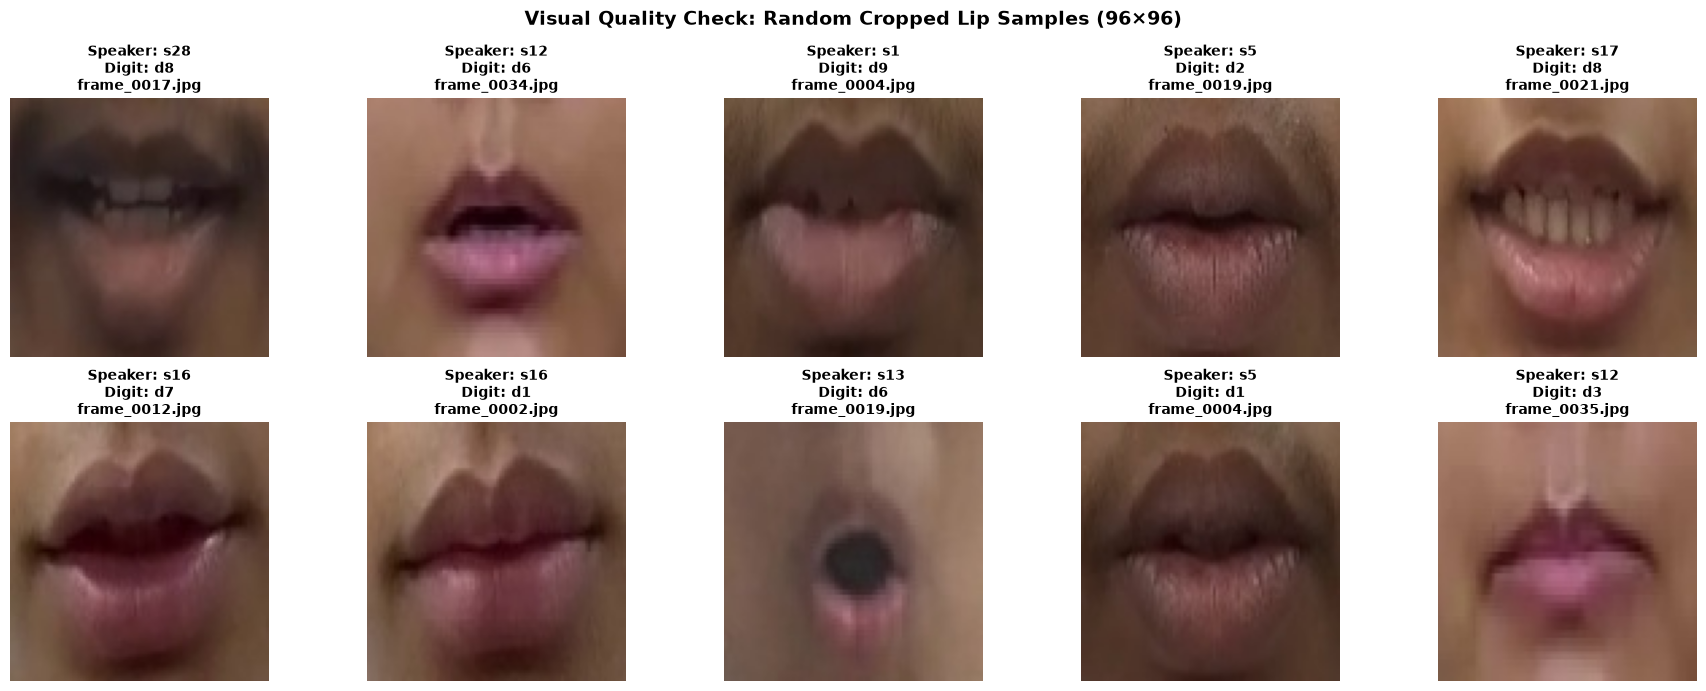

In [22]:
# Cell 12: Visual Quality Check Grid (Random Cross-Speaker & Cross-Digit Samples)
all_cropped_files = sorted([f for f in OUTPUT_ROOT.glob("*/*/*.*") if f.suffix.lower() in VALID_EXTENSIONS])

if len(all_cropped_files) > 0:
    # Select 10 random samples across diverse speakers and digits
    num_samples = min(10, len(all_cropped_files))
    random.seed(42)
    sample_files = random.sample(all_cropped_files, num_samples)

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for i, file_path in enumerate(sample_files):
        img_bgr = cv2.imread(str(file_path))
        if img_bgr is not None:
            if len(img_bgr.shape) == 2 or CONVERT_GRAYSCALE:
                axes[i].imshow(img_bgr, cmap="gray")
            else:
                axes[i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

        speaker = file_path.parent.parent.name
        digit = file_path.parent.name
        filename = file_path.name

        axes[i].set_title(f"Speaker: {speaker}\nDigit: {digit}\n{filename}", fontsize=10, fontweight="bold")
        axes[i].axis("off")

    for j in range(num_samples, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Visual Quality Check: Random Cropped Lip Samples (96×96)", fontsize=14, fontweight="bold")
    plt.tight_layout()

    if SAVE_VISUALIZATIONS:
        grid_save_path = RESULTS_DIR / "quality_check_grid.png"
        plt.savefig(str(grid_save_path), bbox_inches="tight", dpi=150)
        print(f"Quality check grid figure saved to: {grid_save_path}")

    plt.show()
else:
    print("No cropped lip frames found in output dataset to display.")